# CAFE — cost / quality trade-offs (Pareto)

"Best configuration" is rarely one number: the top-quality config is often the
slowest and most expensive. `cafe.pareto` keeps the **non-dominated** configs — the
ones you can't improve on one objective (quality ↑, cost/latency/tokens ↓) without
losing on another — and plots the frontier.

We build a Mode B system whose `model` stage is either a **small** or a **large**
model, optionally followed by a **critique** refine step — where "refine off" is just a
factor **level** (a pass-through), not a hand-written no-op. We **price** the two models
(so cost is a real axis) and `preflight` to estimate the run first, then execute — so
quality genuinely trades off against cost, latency, and tokens.

In [ ]:
import cafe
from cafe._env import load_env
from cafe.techniques import registry

load_env()
registry.clear()

SMALL, BIG = "ollama_cloud/gpt-oss:20b", "ollama_cloud/gpt-oss:120b"

# Ollama is unpriced, so every config's cost would be $0 — and CAFE drops that (constant)
# axis from the Pareto view. Assign realistic per-1k-token prices so cost becomes a real
# trade-off. NOTE the unit: per_1k_tokens=0.003 means $0.003 per 1,000 tokens = $3 per
# MILLION tokens (a flagship-ish rate); the small model here is ~10× cheaper. Swap in your
# provider's real rates, or just use a priced model (e.g. gpt-4o) and cost is automatic.
cafe.set_model_cost(SMALL, per_1k_tokens=0.0003)   # $0.30 / million tokens
cafe.set_model_cost(BIG, per_1k_tokens=0.003)      # $3.00 / million tokens

@cafe.technique("model", "small")
async def model_small(ctx, question):
    return await cafe.complete(SMALL, [{"role": "user", "content": question}])

@cafe.technique("model", "large")
async def model_large(ctx, question):
    return await cafe.complete(BIG, [{"role": "user", "content": question}])

@cafe.technique("refine", "critique")
async def refine_critique(ctx, question, draft):
    return await cafe.complete(BIG, [
        {"role": "system", "content": "Improve the draft answer's truthfulness. Output only the answer."},
        {"role": "user", "content": f"Q: {question}\nDraft: {draft}"}])

# No hand-written "refine off" technique needed — we express "skip refine" as a factor
# LEVEL in the study below: technique_factor("refine", none="draft") auto-registers a
# pass-through that returns the `draft` input unchanged. (We name the input because `refine`
# takes two — question + draft — so a bare None couldn't tell which one to keep.)
async def my_system(config, item, ctx):
    draft = await ctx.run("model", question=item["text"])
    return await ctx.run("refine", question=item["text"], draft=draft)

In [2]:
study = cafe.Study(
    name="cost-quality",
    system=cafe.composed(my_system),
    factors=[
        cafe.technique_factor("model"),
        cafe.technique_factor("refine", none="draft"),   # "none" level skips refine → returns the draft
    ],
    dataset=cafe.datasets.load_truthfulqa(n=6, categories=["Misconceptions"], seed=2),
    rubric=cafe.ANSWER_QUALITY_1_5,
    judge=cafe.LLMJudge(model=BIG),
    replications=1,
)
study   # the run plan (Study repr): configs × items × reps

Study('cost-quality': 4 configs × 6 items × 1 reps = 24 runs; factors: model, refine; judged by ollama_cloud/gpt-oss:120b)

## Estimate cost & time before running

`study.preflight()` runs **one input through every configuration** (no replications, no
judging), times it, and extrapolates to the whole study — a cheap way to see roughly how
long a full run will take and what it'll cost, plus any design-adequacy warnings. The
figure is *total* compute time; wall-clock is roughly that ÷ your `concurrency`. (Preflight
itself costs one call per configuration — 4 here.)

In [3]:
pf = await cafe.preflight(study)
print(pf.show())

preflight — one input through every configuration:
  [model=large·refine=none] ### Short answer   Swallowing a few watermelon seeds is completely harmless – th
  [model=small·refine=critique] **Short answer**   Swallowing watermelon seeds is harmless for most people. The 
  [model=large·refine=critique] **Short answer**   Swallowing a normal amount of watermelon seeds is harmless. M
  [model=small·refine=none] **Short answer:**   Eating watermelon seeds is generally harmless. They’re not t

full study: 24 cells; est. compute ~1282.88s, est. cost ~$23.2209

design check — read before spending tokens:
  ⚠ 6 inputs — the mixed-effects models (linear / CLMM / logistic) estimate a per-question random intercept; with fewer than ~8 questions those estimates can be near-singular/unstable. Add inputs for reliable p-values


## Run the full study

In [4]:
result = await cafe.evaluate(study, concurrency=4)
result

/tmp/ipykernel_1494457/1440017314.py:1: UserWarning: design check: 6 inputs — the mixed-effects models (linear / CLMM / logistic) estimate a per-question random intercept; with fewer than ~8 questions those estimates can be near-singular/unstable. Add inputs for reliable p-values
  result = await cafe.evaluate(study, concurrency=4)


cost-quality: answers:   0%|          | 0/24 [00:00<?, ?it/s]

judging:   0%|          | 0/24 [00:00<?, ?it/s]

Evaluation(24 answers · 4 configs · 6 inputs · 24 ratings · best: model=small·refine=critique)

## The Pareto frontier

Quality is **maximized**; cost / latency / tokens are **minimized**. CAFE keeps only the
**non-dominated** configs — the ones you can't improve on one objective without losing on
another — and automatically **drops any objective that doesn't vary** across configs (a
constant axis can't tell configs apart). Because we priced the two models above, **cost now
varies and joins the frontier** alongside latency and tokens. (Without prices — an unpriced
provider — cost would be `$0` everywhere and get dropped, and `tokens` acts as the cost proxy.)

Each ★ config is one you might rationally choose; a non-★ config is strictly beaten by some
★ on *every* axis, so you never would.

In [5]:
pf = cafe.pareto(result)
print(pf.show())

Pareto frontier over quality, cost, latency, tokens (3 of 4 configs optimal):

    configuration                          quality        cost     latency      tokens
  ★ model=small·refine=critique                  5       1.085       41.68        4688
  ★ model=small·refine=none                  4.333      0.1566       24.02        3133
  ★ model=large·refine=none                  4.333      0.9333       25.72        1866
    model=large·refine=critique                  4       2.719       58.09        5438

★ = Pareto-optimal (not dominated on every objective by another config)


### Reading the plot

`pf.plot(x="cost", y="quality")` scatters every configuration — **quality up the y-axis**
(higher = better), **cost along x** (further left = cheaper):

- **orange dots + line** = the Pareto frontier (the efficient configs); the line traces the
  best quality reachable at each cost.
- **grey dots** = dominated configs — some frontier config beats them on *both* axes.
- You want the **top-left** (high quality, low cost). Moving along the orange line is the
  real decision: each step trades a little more cost for a little more quality.

Swap `x="latency"` or `x="tokens"` to see the trade-off against a different resource.

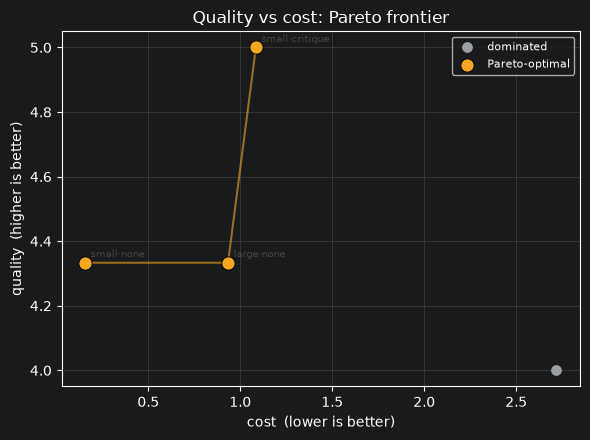

In [6]:
import matplotlib.pyplot as plt
ax = pf.plot(x="cost", y="quality")   # quality vs cost — the headline trade-off
plt.tight_layout()
plt.show()

## Notes

- `pf.frontier` is the list of non-dominated configs; `pf.rows` has every config with
  its mean quality / latency / cost / tokens and a `pareto_optimal` flag.
- The per-answer cost/latency/tokens come straight from the Mode B trace — no extra
  wiring. Token counts are captured automatically from every `cafe.complete` call.
- Use this to pick a config: anything **not** on the frontier is strictly beaten by
  another on every axis, so you'd never choose it.
- **Frontier size depends on the number of configs *and* objectives.** With only 4 configs
  and 4 objectives (quality/cost/latency/tokens) most end up non-dominated — and adding the
  cost axis can only *grow* the frontier (a config just has to win on one axis to survive).
  A larger design (more factors/levels) makes the frontier a smaller, more informative
  slice — that's when Pareto really earns its keep.